In [1]:
import numpy as np
import pandas as pd
from scapy.all import rdpcap, raw
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Memamnggil data
# TRAIN_PCAP_PATH = training.pcap
# TRAIN_LBELS_PATH = label(y) train

# TEST_PCAP_PATH = test.pcap
# TEST_LABELS_PATH = label(y) test

# --- KONFIGURASI DAN PATH FILE ---
BASE_PATH = '/home/dani/Documents/tugas akhir/TugasAkhirku2026/swin_ids/dataTOWIDS/'
BASE_PATHHASIL = '/home/dani/Documents/tugas akhir/TugasAkhirku2026/swin_ids/Preprocessing/hasil_preprocessing/'
TRAIN_PCAP_PATH = BASE_PATH + 'Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap'
TRAIN_LABELS_PATH = BASE_PATH + 'y_train.csv'

# Kita definisikan juga path untuk data testing untuk nanti
TEST_PCAP_PATH = BASE_PATH + 'Automotive_Ethernet_with_Attack_original_10_17_20_04_test.pcap'
TEST_LABELS_PATH = BASE_PATH + 'y_test.csv'

print("Langkah 1 Selesai: Library dan path sudah siap.")

Langkah 1 Selesai: Library dan path sudah siap.


In [3]:
df_train = pd.read_csv(TRAIN_LABELS_PATH)
df_test = pd.read_csv(TEST_LABELS_PATH)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print(df_train.head())
print(df_train.columns)


Train shape: (1203736, 3)
Test shape: (791610, 3)
   1  Normal Normal.1
0  2  Normal   Normal
1  3  Normal   Normal
2  4  Normal   Normal
3  5  Normal   Normal
4  6  Normal   Normal
Index(['1', 'Normal', 'Normal.1'], dtype='object')


In [4]:
df_train = pd.read_csv(TRAIN_LABELS_PATH, header=None)
df_test = pd.read_csv(TEST_LABELS_PATH, header=None)

print(df_train.head())
print(df_train.shape)


   0       1       2
0  1  Normal  Normal
1  2  Normal  Normal
2  3  Normal  Normal
3  4  Normal  Normal
4  5  Normal  Normal
(1203737, 3)


In [5]:
df_train = pd.read_csv(TRAIN_LABELS_PATH, header=None)
df_test = pd.read_csv(TEST_LABELS_PATH, header=None)

# Ambil kolom ke-1 sebagai label utama
y_train_raw = df_train.iloc[:, 1].values
y_test_raw = df_test.iloc[:, 1].values

# Konversi ke binary
y_train = np.where(y_train_raw == "Normal", 0, 1)
y_test = np.where(y_test_raw == "Normal", 0, 1)

print("Distribusi train:", np.unique(y_train, return_counts=True))
print("Distribusi test:", np.unique(y_test, return_counts=True))


Distribusi train: (array([0, 1]), array([954912, 248825]))
Distribusi test: (array([0, 1]), array([660777, 130834]))


In [ ]:
def create_windows(X_pkt, y_pkt, window_size=512):
    """
    Membentuk window dengan overlap 50% (stride = window_size // 2).
    """

    stride = window_size // 2
    num_packets = len(X_pkt)

    X_windows = []
    y_windows = []

    for start in range(0, num_packets - window_size + 1, stride):
        end = start + window_size

        window_data = X_pkt[start:end]
        window_labels = y_pkt[start:end]

        # Label rule: jika ada minimal 1 attack
        window_label = 1 if np.any(window_labels == 1) else 0

        X_windows.append(window_data)
        y_windows.append(window_label)

    return np.array(X_windows), np.array(y_windows)


In [7]:
def extract_packets(packets, n_bytes):
    data = []

    for pkt in packets:
        pkt_bytes = bytes(pkt)

        pkt_fixed = pkt_bytes[:n_bytes]
        if len(pkt_fixed) < n_bytes:
            pkt_fixed += b'\x00' * (n_bytes - len(pkt_fixed))

        data.append(np.frombuffer(pkt_fixed, dtype=np.uint8))

    return np.vstack(data)


In [ ]:
# Load PCAP dulu jika belum
train_packets = rdpcap(TRAIN_PCAP_PATH)
test_packets = rdpcap(TEST_PCAP_PATH)

# Resolusi 32 → M = 32
N_BYTES = 512

X_train_pkt = extract_packets(train_packets, N_BYTES)
X_test_pkt = extract_packets(test_packets, N_BYTES)

print("Train packet shape:", X_train_pkt.shape)
print("Test packet shape:", X_test_pkt.shape)


Train packet shape: (1203737, 512)
Test packet shape: (791611, 512)


In [ ]:
X_train_win, y_train_win = create_windows(X_train_pkt, y_train, window_size=512)
X_test_win, y_test_win = create_windows(X_test_pkt, y_test, window_size=512)

print("Train windows:", X_train_win.shape)
print("Test windows:", X_test_win.shape)


Train windows: (4701, 512, 512)
Test windows: (3091, 512, 512)


In [10]:
unique, counts = np.unique(y_train_win, return_counts=True)
print("Distribusi train window:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test_win, return_counts=True)
print("Distribusi test window:", dict(zip(unique, counts)))


Distribusi train window: {np.int64(0): np.int64(1898), np.int64(1): np.int64(2803)}
Distribusi test window: {np.int64(0): np.int64(1594), np.int64(1): np.int64(1497)}


In [11]:
X_train_win = X_train_win.astype(np.float32) / 255.0
X_test_win  = X_test_win.astype(np.float32) / 255.0

print("Min:", X_train_win.min(), "Max:", X_train_win.max())


Min: 0.0 Max: 1.0


In [12]:
import pywt
def apply_dwt_3wavelets(X_windows):
    """
    Apply 1-level 2D DWT dengan 3 wavelet.
    Output: (num_windows, H/2, W/2, 3)
    """
    X_dwt = []

    for window in X_windows:
        # Wavelet 1
        coeffs1 = pywt.dwt2(window, 'coif1', mode='periodization')
        LL1, _ = coeffs1

        # Wavelet 2
        coeffs2 = pywt.dwt2(window, 'db3', mode='periodization')
        LL2, _ = coeffs2

        # Wavelet 3
        coeffs3 = pywt.dwt2(window, 'rbio1.3', mode='periodization')
        LL3, _ = coeffs3

        # Stack jadi 3 channel
        stacked = np.stack([LL1, LL2, LL3], axis=-1)
        X_dwt.append(stacked)

    return np.array(X_dwt)


In [13]:
X_train_dwt = apply_dwt_3wavelets(X_train_win)
X_test_dwt  = apply_dwt_3wavelets(X_test_win)

print("Train DWT shape:", X_train_dwt.shape)
print("Test DWT shape:", X_test_dwt.shape)


Train DWT shape: (4701, 256, 256, 3)
Test DWT shape: (3091, 256, 256, 3)


In [14]:
# Index berdasarkan label
normal_idx = np.where(y_train_win == 0)[0]
attack_idx = np.where(y_train_win == 1)[0]

# Subset DWT
X_train_normal = X_train_dwt[normal_idx]
X_train_attack = X_train_dwt[attack_idx]

print("Normal shape:", X_train_normal.shape)
print("Attack shape:", X_train_attack.shape)

Normal shape: (1898, 256, 256, 3)
Attack shape: (2803, 256, 256, 3)


In [15]:
print("Min:", X_train_dwt.min())
print("Max:", X_train_dwt.max())


Min: -0.5254788
Max: 2.4145703


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31437927..2.2527132].


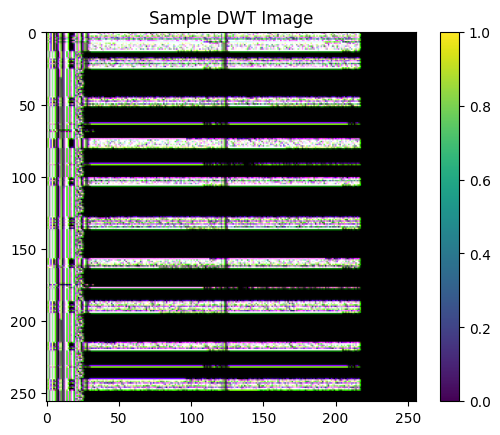

In [16]:
plt.imshow(X_train_dwt[0])
plt.title("Sample DWT Image")
plt.colorbar()
plt.show()


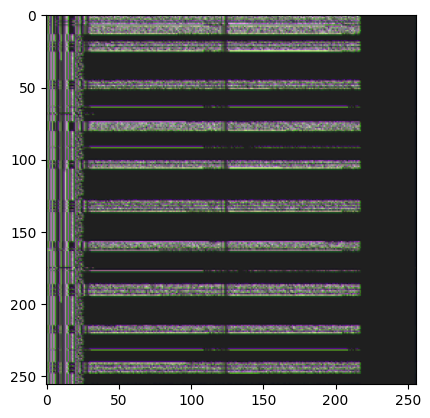

In [17]:
img = X_train_dwt[0]
img_vis = (img - img.min()) / (img.max() - img.min())
plt.imshow(img_vis)
plt.show()


In [ ]:
np.savez_compressed(
    BASE_PATHHASIL + "prep512/swin_res512_dataset.npz",
    X_train=X_train_dwt,
    y_train=y_train_win,
    X_test=X_test_dwt,
    y_test=y_test_win
)


In [ ]:
import os
import cv2  # untuk resize

SAVE_IMG_PATH = BASE_PATHHASIL + "prep512/sample_images/"
os.makedirs(SAVE_IMG_PATH, exist_ok=True)

def save_normalized_samples_with_resize(X, y, num_samples=5, prefix="train", upscale=16):
    saved = 0
    i = 0
    
    while saved < num_samples and i < len(X):
        img = X[i]

        # Normalisasi untuk visualisasi
        img_min = img.min()
        img_max = img.max()
        
        if img_max - img_min != 0:
            img_vis = (img - img_min) / (img_max - img_min)
        else:
            img_vis = img

        # Simpan versi asli 16x16
        plt.imsave(
            SAVE_IMG_PATH + f"{prefix}_sample_{i}_label_{y[i]}_original.png",
            img_vis
        )

        # Resize (misal 16x)
        new_size = (img_vis.shape[1] * upscale, img_vis.shape[0] * upscale)
        img_resized = cv2.resize(img_vis, new_size, interpolation=cv2.INTER_NEAREST)

        plt.imsave(
            SAVE_IMG_PATH + f"{prefix}_sample_{i}_label_{y[i]}_zoom.png",
            img_resized
        )

        saved += 1
        i += 1

save_normalized_samples_with_resize(X_train_dwt, y_train_win, num_samples=5, prefix="train")
save_normalized_samples_with_resize(X_test_dwt, y_test_win, num_samples=5, prefix="test")

print("Original and zoomed images saved.")


Original and zoomed images saved.
